# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [1]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

c:\Users\rjrso\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

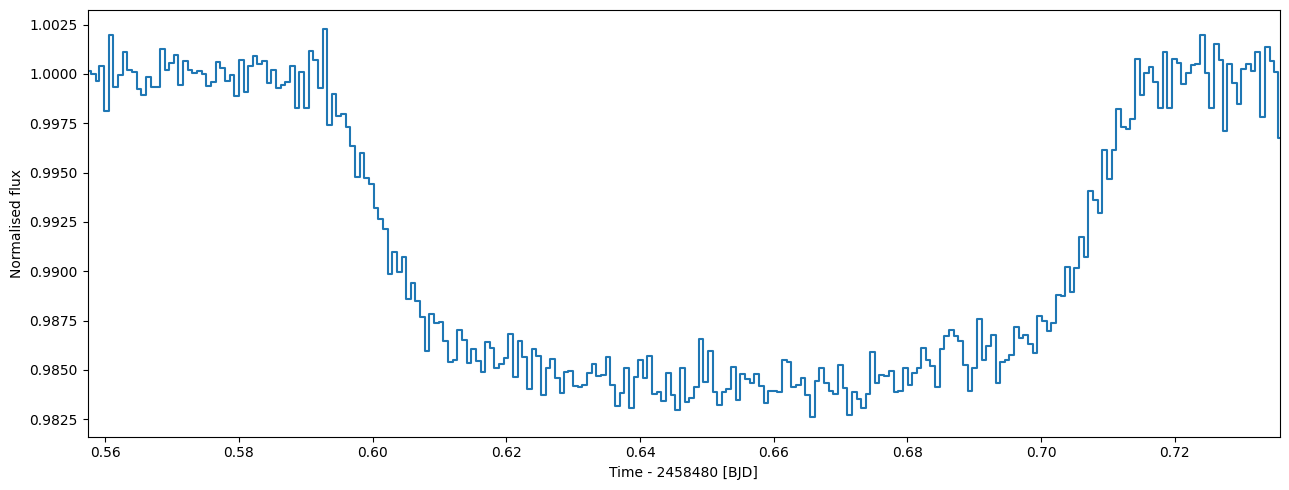

In [3]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

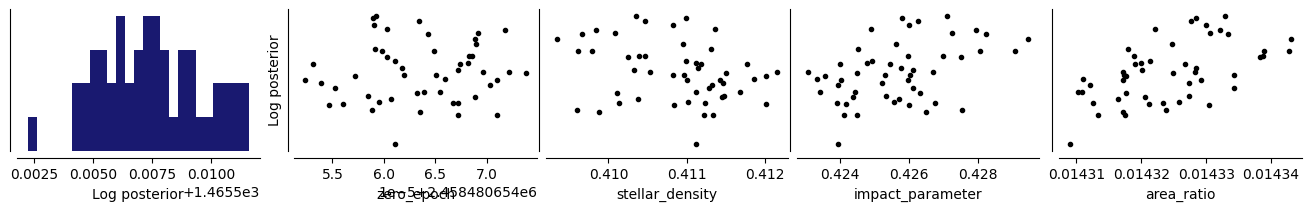

In [7]:
lpf.optimize_global(niter=500, npop=50)

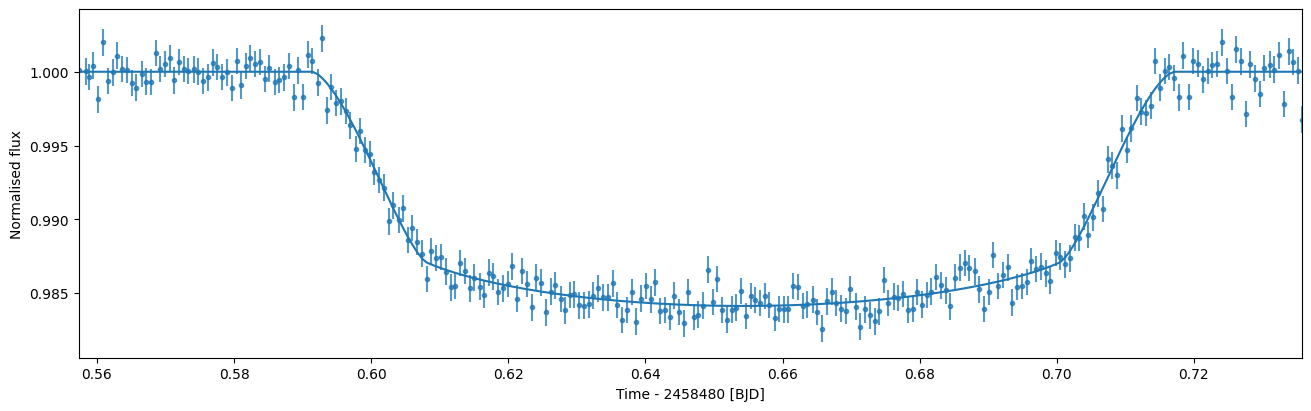

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling: 100%|██████████| 2/2 [01:11<00:00, 35.67s/it]


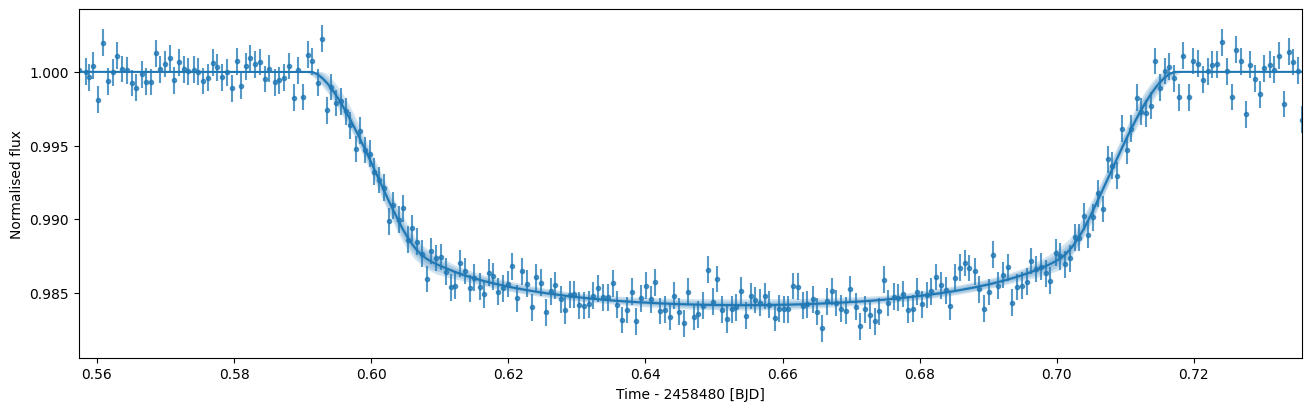

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

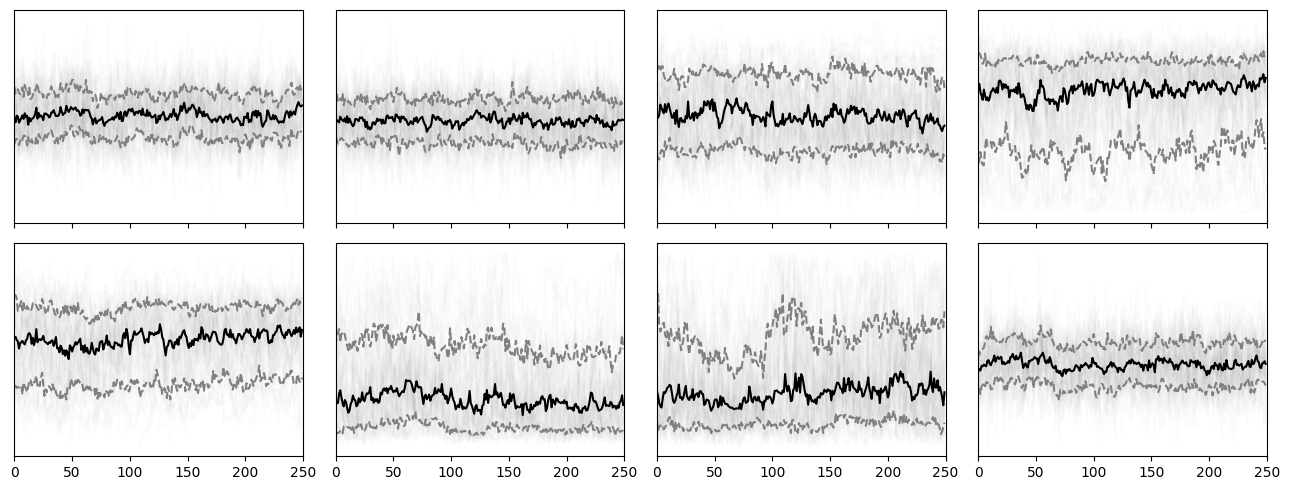

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

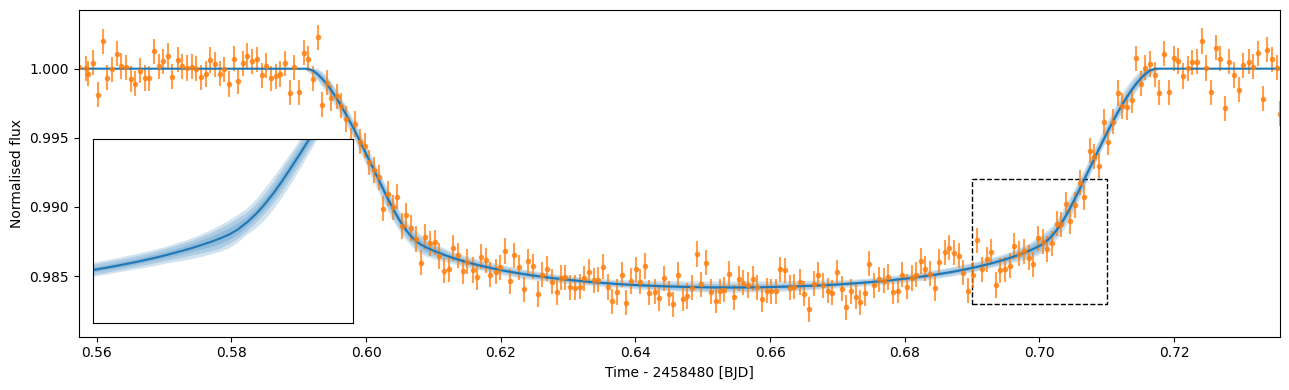

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4364,3.2628e-01,0.0139,0.3298,0.3310,-3.0401,0.1180,3.0153,1.4610,0.1258,0.0948
std,1.5944e-04,1.1052e-09,0.0380,1.3094e-01,0.0005,0.2039,0.2312,0.0193,0.0020,0.0876,0.0461,0.0010,0.0027
min,2.4585e+06,1.0914e+00,0.3313,9.6471e-05,0.0126,0.0474,0.0003,-3.1093,0.1122,2.7528,1.3650,0.1220,0.0867
25%,2.4585e+06,1.0914e+00,0.4073,2.4841e-01,0.0136,0.1676,0.1493,-3.0530,0.1164,2.9490,1.4257,0.1252,0.0926
50%,2.4585e+06,1.0914e+00,0.4340,3.6308e-01,0.0140,0.2748,0.2699,-3.0404,0.1183,3.0121,1.4500,0.1258,0.0945
75%,2.4585e+06,1.0914e+00,0.4661,4.2660e-01,0.0143,0.4493,0.4688,-3.0271,0.1196,3.0846,1.4903,0.1265,0.0970
max,2.4585e+06,1.0914e+00,0.5355,5.6480e-01,0.0151,1.0000,1.0000,-2.9464,0.1230,3.2308,1.5708,0.1296,0.1015


<Axes: >

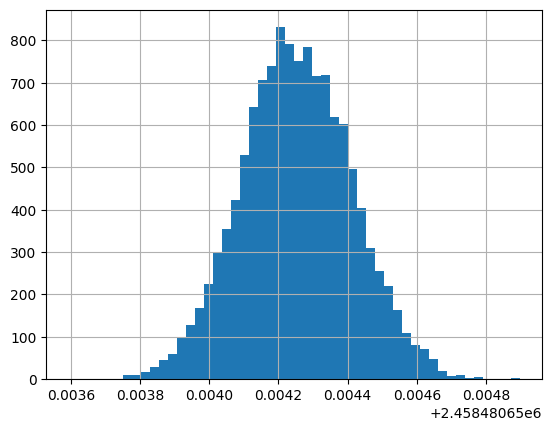

In [16]:
df.tc.hist(bins=50)

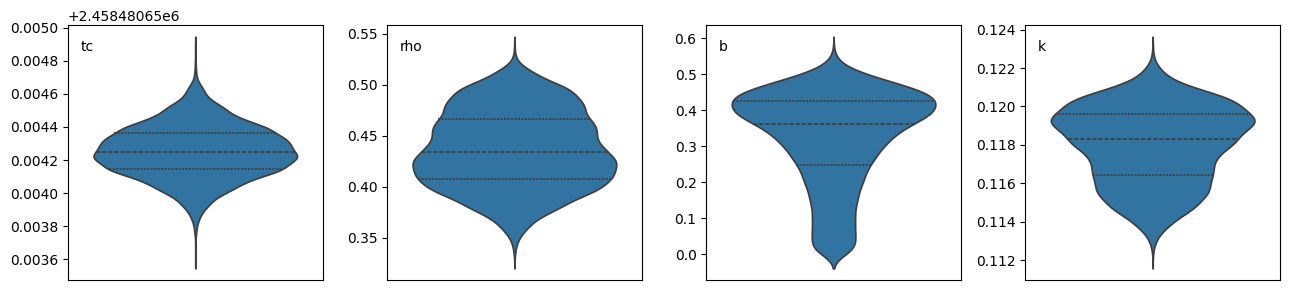

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

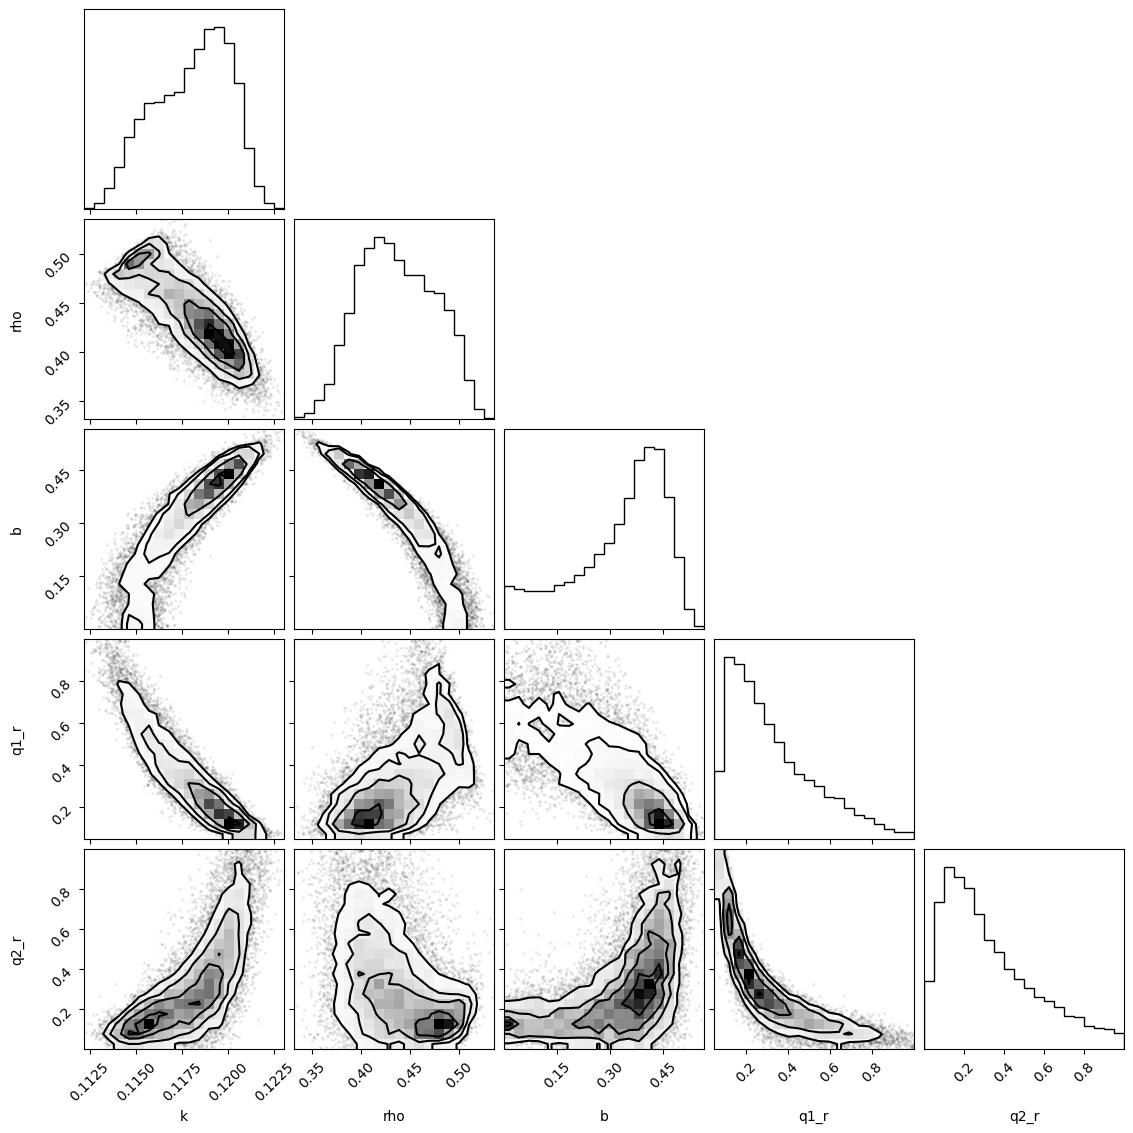

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

I have taken the stellar radius from [Leonardi et al (2024)](https://arxiv.org/abs/2402.12120), $R_*=1.690R_\odot$. The planet's radius is $R_p=k R_*$

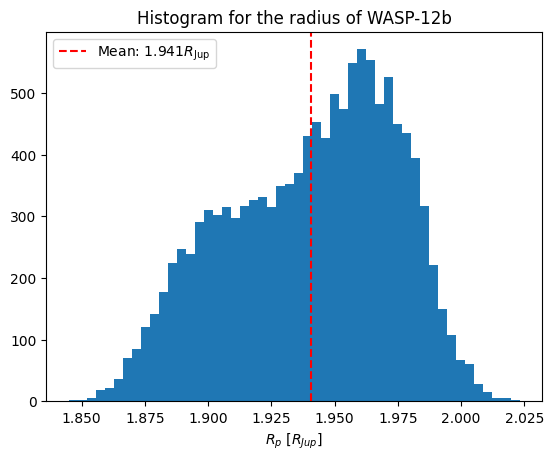

In [19]:
from astropy import constants as const
import matplotlib.pyplot as plt
import numpy as np

M_star = 1.325 * const.M_sun                    #  kg
R_star = 1.690 * const.R_sun                    #  m 
R_p = df.k * R_star / const.R_jup               #  R_jup

plt.hist(R_p, bins=50);
plt.xlabel(r"$R_p\ [R_{Jup}]$");
plt.axvline(np.mean(R_p), c='r', ls='dashed', label=f"Mean: ${np.mean(R_p):.3f}R_{{\\mathrm{{Jup}}}}$")
plt.legend(loc="upper left");
plt.title("Histogram for the radius of WASP-12b");

This result for the radius of the planet is not compatible with that indicated in the aforementioned article, which states it is $(1.825\pm 0.091)R_\mathrm{Jup}$. It is compatible however with that indicated by [NASA](https://science.nasa.gov/exoplanet-catalog/wasp-12-b/) and the [Extrasolar Planets Encyclopedia](https://exoplanet.eu/catalog/wasp_12_ab--459/), $1.965R_\mathrm{Jup}$ and $1.90^{+0.057}_{-0.056}R_\mathrm{Jup}$ respectively, which are based on more recent data ([Collins et al. 2017](https://arxiv.org/abs/1512.00464)) with higher quality.

2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

In order to do so, we recreate the mass distribution seen in the previous notebook. Recall that its parameters are $\mu=1.3415M_\mathrm{Jup}$  and $\sigma=0.0118M_\mathrm{Jup}$.

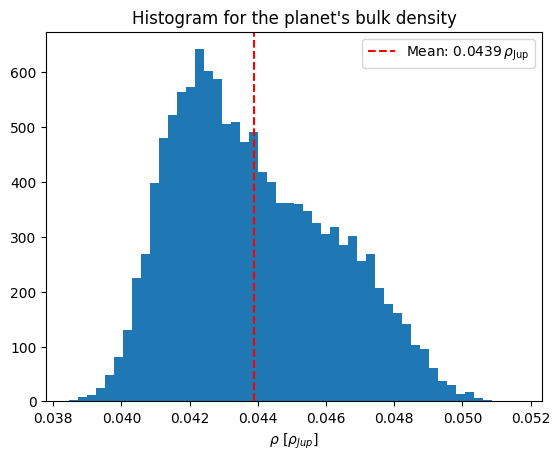

In [20]:
from scipy.stats import norm

mp_mu = 1.3415                                          #  M_jup
mp_std = 0.0118                                         #  M_jup
mpsini = np.random.normal(mp_mu, mp_std, len(R_p))      #  M_jup
dens = mpsini / (4/3 * np.pi * R_p**3)                  #  rho_jup
dens_mean = np.mean(dens)                               #  rho_jup
dens_std = np.std(dens)                                 #  rho_jup

plt.hist(dens, bins=50);
plt.title("Histogram for the planet's bulk density")
plt.xlabel(r"$\rho\ [\rho_{Jup}]$")
plt.axvline(dens_mean, c="r", ls="dashed", label=f"Mean: ${dens_mean:.4f}\\,\\rho_{{\\mathrm{{Jup}}}}$")
plt.legend();

3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- By adding observations from the transit method, we can find out the planet's inclination (i), thus obtaining the 'true mass'. 
   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

- As we commented on the previous notebook, we are dealing with a 'Hot Jupiter' kind of planet. However, the bulk density distribution obtained in this notebook indicates that its density is much lower than that of Jupiter. In the literature it is mentioned that this planet is inflated, which explains the low density.

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

- The transit modelling estimate of the stellar density can be seen in the variable 'df.rho'. We will perform the average over all the values calculated and store the result in the variable 'dens_estimated'. 

* On the other hand, if we want to calculate the theoretical value of the stellar density, we use the formula for the density, $\rho_*=\frac{M_*}{4/3 \pi R_*}$, and input the data found in the aforementioned literature, we will store the result in the variable 'dens_theo'.

In [21]:
dens_sun = const.M_sun / (4/3*np.pi*const.R_sun**3)                                    #  kg cm^-3
dens_estimated = np.mean(df.rho)                                                       #  gcm^-3
dens_estimated = dens_estimated * 1000 / dens_sun                                      #  rho_sun
print(f"Estimated density of the star is: {(dens_estimated.value):.3f} rho_sun")

M_star = 1.325 * const.M_sun                                                           #  kg
R_star = 1.690 * const.R_sun                                                           #  m
dens_theo = M_star / (4/3*np.pi*R_star**3)                                             #  kg cm^-3
dens_theo = dens_theo / dens_sun                                                       #  rho_sun
print(f"Theoretical density of the star is: {(dens_theo):.3f} rho_sun")

Estimated density of the star is: 0.310 rho_sun
Theoretical density of the star is: 0.275 rho_sun


* As we can see, there is a difference between both values, which may be explained by the uncertainty associated to the distribution or the uncertainty from the theoretical mass and radius of the star.

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- If two parameters are correlated, we can estimate one based on the measurement of the other. In practice, this expands the information we can obtain from an observation using a single method.

---
<center>&copy;2026 Hannu Parviainen</center>